## Building Agent that use Code

In [1]:
from huggingface_hub import notebook_login

notebook_login()

d:\HF AI Agent Course\hf_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from smolagents import CodeAgent, InferenceClientModel, tool

@tool
def catering_service_tool(query: str) -> str:
    """
    This tool returns the highest-rated catering service in New York City.

    Args:
        query: A search term for finding catering services.
    """
    # Example list of catering services and their ratings
    services = {
        "New York Catering Co.": 4.9,
        "Wayne Manor Catering": 4.8,
        "New York City Events": 4.7,
    }

    best_service = max(services, key=services.get)

    return best_service

agent = CodeAgent(tools=[catering_service_tool], model=InferenceClientModel(model_id="Qwen/Qwen2.5-Coder-32B-Instruct"))

result = agent.run(
    "Can you give me the name of the highest-rated catering service in NewYork City?"
)

print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Can you give me the name of the highest-rated catering service in NewYork City?                                 │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  highest_rated_catering_service = catering_service_tool(query="highest-rated catering service in New York City")  
  print(highest_rated_catering_service)                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
New York Catering Co.

Out: None

[Step 1: Duration 2.41 seconds| Input tokens: 2,083 | Output tokens: 63]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  highest_rated_catering_service = "New York Catering Co."                                                         
  final_answer(highest_rated_catering_service)                                                                     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: New York Catering Co.

[Step 2: Duration 2.25 seconds| Input tokens: 4,327 | Output tokens: 128]

New York Catering Co.


### Importing Tool from the Hub

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate an image of a luxurious superhero-themed party at Wayne Manor with MARVEL superheros.                  │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  prompt = "A luxurious superhero-themed party at Wayne Manor featuring Marvel superheroes. The scene is grand     
  and elegant, with a large ballroom adorned with red velvet curtains and chandeliers. Decorations include large   
  cutouts of famous Marvel characters, colorful balloons, and themed tableware. Superheroes such as Iron Man,      
  Spider-Man, Thor, and Black Panther mingle with guests wearing superhero masks and costumes, enjoying gourmet    
  food and drinks. The atmosphere is festive and vibrant, capturing the essence of both luxury and comic book      
  excitement."                                                                                                     
  image = image_generator(prompt=prompt)                                                                           
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x768 at 0x1F60A24ED80>

[Step 1: Duration 8.60 seconds| Input tokens: 2,111 | Output tokens: 155]

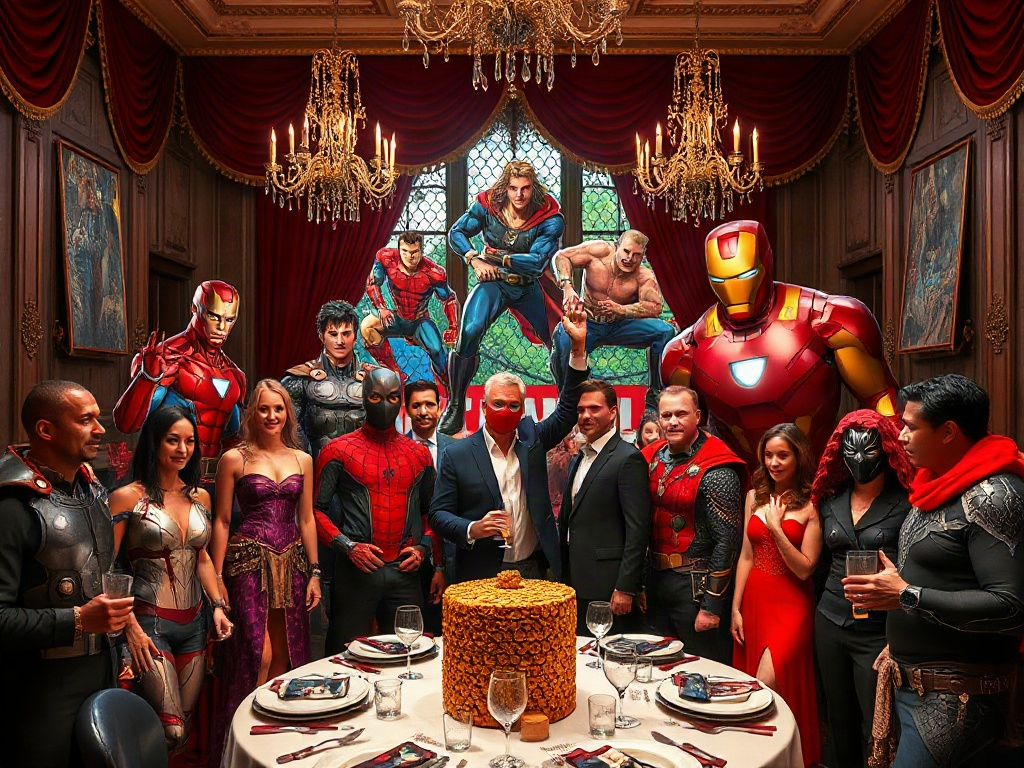

In [7]:
from smolagents import load_tool, CodeAgent, InferenceClientModel

image_generation_tool = load_tool(
    "m-ric/text-to-image",
    trust_remote_code=True
)

agent = CodeAgent(
    tools=[image_generation_tool],
    model=InferenceClientModel(model_id="Qwen/Qwen2.5-Coder-32B-Instruct")
)

agent.run("Generate an image of a luxurious superhero-themed party at Wayne Manor with MARVEL superheros.")

In [ ]:
#! pip install gradio_client


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from smolagents import CodeAgent, InferenceClientModel, load_tool

image_generation_tool = load_tool(
    "m-ric/text-to-image",
    trust_remote_code=True
)

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct"
)

agent = CodeAgent(
    tools=[image_generation_tool],
    model=model
)

result = agent.run(
    "Improve this prompt, then generate an image of it.",
    additional_args={
        "user_prompt": "A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala"
    }
)

print(result)


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Improve this prompt, then generate an image of it.                                                              │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'user_prompt': 'A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala'}.      │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  refined_prompt = "A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala.        
  High-res, photorealistic, elegant decor, colorful costumes, bustling crowd, iconic superhero characters,         
  glamorous atmosphere."                                                                                           
  print(refined_prompt)                                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala. High-res, photorealistic, 
elegant decor, colorful costumes, bustling crowd, iconic superhero characters, glamorous atmosphere.

Out: None

[Step 1: Duration 2.68 seconds| Input tokens: 2,146 | Output tokens: 90]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  image = image_generator(prompt=refined_prompt)                                                                   
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x768 at 0x1F60A384B30>

[Step 2: Duration 11.44 seconds| Input tokens: 4,529 | Output tokens: 140]

C:\Users\nmana\AppData\Local\Temp\tmpwefa9vr1\5bc5b434-1468-4673-bc66-463aebc99e8f.png
